# Customer Churn & Retention Analysis

### Executive Summary

This analysis investigates customer drop-off, subscription health, and support metrics across a 500-user dataset to identify key drivers of churn and quantify the financial impact.

**Key Findings:**
* **High Churn & Revenue Impact:** The current churn rate sits at 32.8%, leaving a retention rate of 67.2%. This drop-off currently represents **$3,107.36** in revenue at risk.
* **The Escalation Pipeline:** There is a severe positive correlation (**0.88**) between customer support escalations and churn. With an overall escalation rate of 30.8% and an average of 0.74 complaints per user, support interactions are the primary bottleneck for retention. 
* **Plan Vulnerability:** Basic plan subscribers are churning at the highest rate (36.87%), compared to Premium (30.12%) and Standard (30.96%) users.
* **Customer Baseline:** The average customer is 38 years old, has a tenure of 510 days, and yields an Average Revenue Per User (ARPU) of $19.37.

**Strategic Takeaway:** 
Immediate intervention is required in the customer support escalation process. Because escalations are nearly perfectly correlated with customers leaving, resolving tickets before they escalate is the single highest-leverage action the business can take to secure the $3,100+ in at-risk revenue.

In [1]:
# import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings("ignore")

## 1. Import Database

In [ ]:
server = 'server name'
database = 'customer_churn'

# If using a SQL username/password, use: f"mssql+pyodbc://{username}:{password}@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server"
connection_uri = f"mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server&Trusted_Connection=yes"

engine = create_engine(connection_uri)

sql_query = """
            SELECT TABLE_NAME AS name
            FROM INFORMATION_SCHEMA.TABLES
            WHERE TABLE_TYPE = 'BASE TABLE';
            """

tables = pd.read_sql(sql_query, engine)

dfs: dict[str, pd.DataFrame] = {}

for table_name in tables['name']:
    df=pd.read_sql(f"SELECT * FROM {table_name}", engine)
    dfs[table_name] = df
    print(f"Loaded DataFrame for table: {table_name}")
    #globals()[f"df_{table_name}"] = df
    #print(f"created dataframe: df_{table_name}")


engine.dispose()

Loaded DataFrame for table: db_customer
Loaded DataFrame for table: db_subscription
Loaded DataFrame for table: db_support


In [3]:
for table_name in tables['name']:

    print(f"\nTable Name: {table_name}")

    columnn_query = f"""
                SELECT COLUMN_NAME AS name
                FROM INFORMATION_SCHEMA.COLUMNS
                WHERE TABLE_NAME = '{table_name}' 
                ORDER BY ORDINAL_POSITION;
                """
    columns = pd.read_sql(columnn_query, engine)
    
    print('columns:')
    print(columns['name'].tolist())

engine.dispose()


Table Name: db_customer
columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
columns:
['customerid', 'subscription_start_date', 'subscription_type', 'plan_type', 'contract_type', 'renewal_date', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
columns:
['ticket_id', 'customerid', 'complaint_date', 'escalations', 'csat_score']


## 2. Data Cleaning

In [4]:
dfs['db_customer'].head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0001-LQYDZ,Kavita Tamang,NaN,Karnataka,Men,Sep 23 1972 12:00AM,Sports,560576
1,0002-BMHUM,Gaurav Thapa,Nepal,Lumbini,Men,Mar 21 2002 12:00AM,"Movies, Sports",32946
2,0003-FRGBT,Ruhul Singh,NaN,Koshi,Female,Mar 20 1990 12:00AM,Sports,56732
3,0004-XTZNT,Rohan Patel,India,Madhya Pradesh,Female,Jan 1 1977 12:00AM,Web Series,462841
4,0005-MFNWY,Ruhul Kumar,NaN,NaN,Men,Jul 10 1993 12:00AM,"Movies, Sports",395075


In [5]:
dfs['db_customer'].tail()

,customerid,name,country,state,gender,dob,interests,pincode
495,0496-CZLJT,Sunita Smith,India,Odisha,Female,Feb 19 1989 12:00AM,"Movies, Sports",751071
496,0497-LLFIP,Vikram Singh,India,Punjab,Women,Sep 20 1975 12:00AM,"Movies, Sports",144228
497,0498-QDOFC,Anjali Karki,India,NaN,Male,May 12 1973 12:00AM,Sports,462315
498,0499-MWYTQ,Ravi Singh,NaN,Assam,Male,Apr 15 1988 12:00AM,"Movies, Sports",781299
499,0500-NOYFI,Anjali Yadav,India,Delhi,Male,Jul 11 1985 12:00AM,"Movies, Sports",110043


In [6]:
dfs['db_customer'].info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   customerid  500 non-null    str  
 1   name        500 non-null    str  
 2   country     412 non-null    str  
 3   state       341 non-null    str  
 4   gender      500 non-null    str  
 5   dob         500 non-null    str  
 6   interests   500 non-null    str  
 7   pincode     500 non-null    str  
dtypes: str(8)
memory usage: 31.4 KB


In [7]:
# renaming the name column to customer_name

dfs['db_customer'].rename(columns = {'name' : 'customer_name'}, inplace = True)

In [8]:
dfs['db_customer']['gender'].unique()

<StringArray>
['Men', 'Female', 'Women', 'Male']
Length: 4, dtype: str

In [9]:
# changing the 'Men'/'Women' to 'Male'/'Female'

dfs['db_customer']['gender'] = dfs['db_customer']['gender'].replace({ 'Men' : 'Male' , 'Women' : 'Female'})

In [10]:
# changing the datatype of dob column from str to datetime

dfs['db_customer']['dob'] = pd.to_datetime(dfs['db_customer']['dob'])

In [11]:
dfs['db_customer'][dfs['db_customer']['state'].isna()]

,customerid,customer_name,country,state,gender,dob,interests,pincode
4,0005-MFNWY,Ruhul Kumar,NaN,NaN,Male,1993-07-10,"Movies, Sports",395075
6,0007-XWJAC,Sanjay Patel,Nepal,NaN,Male,1984-07-20,"Movies, Sports",44753
7,0008-GUQGV,Sunita Kumar,Nepal,NaN,Female,1972-09-04,"Documentaries, Live TV",44386
14,0015-DFKLV,Rohan Adhikari,NaN,NaN,Male,2003-05-30,Sports,110247
15,0016-ESTQZ,Sunita Karki,India,NaN,Male,1977-07-24,"Documentaries, Live TV",110192
...,...,...,...,...,...,...,...,...
485,0486-IRLSJ,Gaurav Smith,India,NaN,Male,1976-10-28,"Movies, Sports",600568
486,0487-HNLPA,Aisha Yadav,India,NaN,Female,1989-06-15,"Documentaries, Live TV",500826
488,0489-ARDYM,Sanjay Chaudhary,India,NaN,Female,1976-11-08,Web Series,226611
490,0491-SPWRL,Ravi Kumar,India,NaN,Male,1971-07-28,Web Series,395161


In [12]:
#Fixing the missing values in state column.

df_cust = dfs['db_customer']

df_cust['pin_prefix'] = df_cust['pincode'].astype(str).str[:3]

#pincode_state_mapping = df_cust.dropna(subset=['state']).drop_duplicates('pin_prefix').set_index('pin_prefix')['state'].to_dict()
pincode_state_mapping = df_cust.dropna(subset=['state']).groupby('pin_prefix')['state'].first().to_dict()

master_pincode_map = {
    '110': 'Delhi', '144': 'Punjab', '226': 'Uttar Pradesh', '302': 'Rajasthan', 
    '395': 'Gujarat', '400': 'Maharashtra', '462': 'Madhya Pradesh', '500': 'Telangana', 
    '560': 'Karnataka', '600': 'Tamil Nadu', '695': 'Kerala', '700': 'West Bengal', 
    '751': 'Odisha', '781': 'Assam', '800': 'Bihar',
    '446': 'Kathmandu', '447': 'Bagmati', '443': 'Madhesh', '337': 'Gandaki', 
    '329': 'Lumbini', '567': 'Koshi', '212': 'Karnali', '109': 'Sudurpashchim'
}

master_pincode_map.update(pincode_state_mapping)

df_cust['state'] = df_cust['state'].fillna(df_cust['pin_prefix'].map(master_pincode_map))

df_cust.drop(columns=['pin_prefix'], inplace=True)

dfs['db_customer'] = df_cust

dfs['db_customer'].info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     500 non-null    str           
 1   customer_name  500 non-null    str           
 2   country        412 non-null    str           
 3   state          500 non-null    str           
 4   gender         500 non-null    str           
 5   dob            500 non-null    datetime64[us]
 6   interests      500 non-null    str           
 7   pincode        500 non-null    str           
dtypes: datetime64[us](1), str(7)
memory usage: 31.4 KB


In [13]:
#Fixing the missing values in country column.

country_state_mapping = dfs['db_customer'].dropna(subset='country').set_index('state')['country'].to_dict()

dfs['db_customer']['country'] = dfs['db_customer']['country'].fillna(dfs['db_customer']['state'].map(country_state_mapping))

In [14]:
dfs['db_customer'].info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     500 non-null    str           
 1   customer_name  500 non-null    str           
 2   country        500 non-null    str           
 3   state          500 non-null    str           
 4   gender         500 non-null    str           
 5   dob            500 non-null    datetime64[us]
 6   interests      500 non-null    str           
 7   pincode        500 non-null    str           
dtypes: datetime64[us](1), str(7)
memory usage: 31.4 KB


In [15]:
dfs['db_subscription'].head()

,customerid,subscription_start_date,subscription_type,plan_type,contract_type,renewal_date,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0001-LQYDZ,Jul 27 2023 7:15PM,Paid,standard,Annually,Jul 1 2027 7:15PM,NaN,NaN,26.99,1287.0,1
1,0002-BMHUM,Nov 21 2023 7:15PM,Organic,standard,Annually,Mar 4 2027 7:15PM,NaN,NaN,26.99,553.0,28
2,0003-FRGBT,Sep 8 2025 7:15PM,Organic,standard,Annually,May 14 2027 7:15PM,NaN,NaN,27.99,293.0,21
3,0004-XTZNT,May 3 2025 7:15PM,Paid,premium,Monthly,Sep 21 2026 7:15PM,Jul 8 2026 7:15PM,Too expensive,17.99,464.0,95
4,0005-MFNWY,Aug 11 2025 7:15PM,Refferal,basic,Monthly,Jun 17 2027 7:15PM,NaN,NaN,16.99,364.0,9


In [16]:
dfs['db_subscription'].info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               500 non-null    str    
 1   subscription_start_date  500 non-null    str    
 2   subscription_type        500 non-null    str    
 3   plan_type                500 non-null    str    
 4   contract_type            500 non-null    str    
 5   renewal_date             500 non-null    str    
 6   cancellation_date        164 non-null    str    
 7   cancellation_reason      164 non-null    str    
 8   monthly_charges          500 non-null    float64
 9   cltv                     500 non-null    float64
 10  churn_score              500 non-null    int64  
dtypes: float64(2), int64(1), str(8)
memory usage: 43.1 KB


In [17]:
# change datatype to datetime and extract the date from the date time - subscription_start_date, renewal_date, cancellation_date  

date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

dfs['db_subscription'][date_col] = dfs['db_subscription'][date_col].apply(lambda x : pd.to_datetime(x).dt.normalize())


In [18]:
dfs['db_support'].head()

,ticket_id,customerid,complaint_date,escalations,csat_score
0,1,0004-XTZNT,Jul 3 2026 7:15PM,Y,1.0
1,2,0006-CITDZ,Jun 8 2026 7:15PM,Y,2.0
2,3,0007-XWJAC,May 7 2026 7:15PM,N,3.0
3,4,0008-GUQGV,Mar 24 2026 7:15PM,N,1.0
4,5,0014-ICGAL,Apr 6 2026 7:15PM,Y,2.0


In [19]:
dfs['db_support'].info()

<class 'pandas.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ticket_id       372 non-null    int64  
 1   customerid      372 non-null    str    
 2   complaint_date  372 non-null    str    
 3   escalations     372 non-null    str    
 4   csat_score      372 non-null    float64
dtypes: float64(1), int64(1), str(3)
memory usage: 14.7 KB


In [20]:
#change datatype to datetime and extract the date from the date time

dfs['db_support']['complaint_date'] = pd.to_datetime(dfs['db_support']['complaint_date'], format= '%b %d %Y %I:%M%p').dt.normalize()

## 3. Feature Engineering & Data Analysis

In [21]:
# creating a new column "churn_flag" in subscription table.

dfs['db_subscription']['churn_flag'] = np.where(dfs['db_subscription']['cancellation_date'].notna(), 1,0)

dfs['db_subscription'].head()

,customerid,subscription_start_date,subscription_type,plan_type,contract_type,renewal_date,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0001-LQYDZ,2023-07-27,Paid,standard,Annually,2027-07-01,NaT,NaN,26.99,1287.0,1,0
1,0002-BMHUM,2023-11-21,Organic,standard,Annually,2027-03-04,NaT,NaN,26.99,553.0,28,0
2,0003-FRGBT,2025-09-08,Organic,standard,Annually,2027-05-14,NaT,NaN,27.99,293.0,21,0
3,0004-XTZNT,2025-05-03,Paid,premium,Monthly,2026-09-21,2026-07-08,Too expensive,17.99,464.0,95,1
4,0005-MFNWY,2025-08-11,Refferal,basic,Monthly,2027-06-17,NaT,NaN,16.99,364.0,9,0


In [22]:
print(dfs['db_customer'].shape)
print(dfs['db_subscription'].shape)
print(dfs['db_support'].shape)

(500, 8)
(500, 12)
(372, 5)


In [23]:
print("dfs['db_customer'] unique value:", dfs['db_customer']['customerid'].nunique())
print("dfs['db_subscription'] unique value:", dfs['db_subscription']['customerid'].nunique())
print("dfs['db_support'] unique value:", dfs['db_support']['customerid'].nunique())
print("dfs['db_support'] all value:", dfs['db_support']['customerid'].size)

dfs['db_customer'] unique value: 500
dfs['db_subscription'] unique value: 500
dfs['db_support'] unique value: 301
dfs['db_support'] all value: 372


In [24]:
# adding a complaint_count column to store the count of a customer raising one or multiple complaints.

dfs['db_support']['complaint_count'] = dfs['db_support'].groupby('customerid')['customerid'].transform('count')

In [25]:
# keeping only one record of the last complaint from each customerid.

dfs['db_support'] = dfs['db_support'].sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [26]:
print("dfs['db_support'] unique value:", dfs['db_support']['customerid'].nunique())
print("dfs['db_support'] all value:", dfs['db_support']['customerid'].size)

dfs['db_support'] unique value: 301
dfs['db_support'] all value: 301


#### Merge Dataframes - JOINs

In [27]:
# merging all the tables into one complete table

df = (dfs['db_customer']
      .merge(dfs['db_subscription'], on = 'customerid', how = 'left')
      .merge(dfs['db_support'], on = 'customerid', how = 'left'))

In [28]:
df.shape

(500, 24)

In [29]:
df.head()

,customerid,customer_name,country,state,gender,dob,interests,pincode,subscription_start_date,subscription_type,...,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,ticket_id,complaint_date,escalations,csat_score,complaint_count
0,0001-LQYDZ,Kavita Tamang,India,Karnataka,Male,1972-09-23,Sports,560576,2023-07-27,Paid,...,NaN,26.99,1287.0,1,0,165.0,2026-05-09,N,5.0,1.0
1,0002-BMHUM,Gaurav Thapa,Nepal,Lumbini,Male,2002-03-21,"Movies, Sports",32946,2023-11-21,Organic,...,NaN,26.99,553.0,28,0,NaN,NaT,NaN,NaN,NaN
2,0003-FRGBT,Ruhul Singh,Nepal,Koshi,Female,1990-03-20,Sports,56732,2025-09-08,Organic,...,NaN,27.99,293.0,21,0,NaN,NaT,NaN,NaN,NaN
3,0004-XTZNT,Rohan Patel,India,Madhya Pradesh,Female,1977-01-01,Web Series,462841,2025-05-03,Paid,...,Too expensive,17.99,464.0,95,1,302.0,2026-07-07,Y,1.0,2.0
4,0005-MFNWY,Ruhul Kumar,India,Gujarat,Male,1993-07-10,"Movies, Sports",395075,2025-08-11,Refferal,...,NaN,16.99,364.0,9,0,NaN,NaT,NaN,NaN,NaN


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               500 non-null    str           
 1   customer_name            500 non-null    str           
 2   country                  500 non-null    str           
 3   state                    500 non-null    str           
 4   gender                   500 non-null    str           
 5   dob                      500 non-null    datetime64[us]
 6   interests                500 non-null    str           
 7   pincode                  500 non-null    str           
 8   subscription_start_date  500 non-null    datetime64[us]
 9   subscription_type        500 non-null    str           
 10  plan_type                500 non-null    str           
 11  contract_type            500 non-null    str           
 12  renewal_date             500 non-null    dateti

In [31]:
# export dataframe to csv file

df.to_csv('churn_data_cleaned.csv', index= False)

In [32]:
# churn rate

churn_rate = df['churn_flag'].mean()*100

print("Churn Rate = ", round(churn_rate, 2), "%")

Churn Rate =  32.8 %


In [33]:
# retention rate

retention_rate = 100 - churn_rate

print("Retention Rate = ", round(retention_rate, 2), "%")

Retention Rate =  67.2 %


In [34]:
# churn by plan type

churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).reset_index(name = 'churn_rate_pct')

print(churn_by_plan)

  plan_type  churn_rate_pct
0     basic       36.871508
1   premium       30.120482
2  standard       30.967742


In [35]:
# Churn by state + sum(revenue) & count of users

state_summary = df.groupby('state').agg(
    churn_rate_pct = ('churn_flag', 'mean'),
    total_revenue = ('monthly_charges', 'sum'),
    user_count = ('customerid', 'count')
).reset_index()

state_summary['churn_rate_pct'] = state_summary['churn_rate_pct']*100

print(state_summary)

             state  churn_rate_pct  total_revenue  user_count
0            Assam       40.909091         404.78          22
1          Bagmati       29.729730         732.63          37
2            Bihar       15.384615         297.87          13
3            Delhi       37.500000         469.76          24
4          Gandaki       21.621622         694.63          37
5          Gujarat       31.250000         295.84          16
6          Karnali       52.380952         419.79          21
7        Karnataka       34.782609         479.77          23
8        Kathmandu       37.037037         506.73          27
9           Kerala       36.363636         238.89          11
10           Koshi       25.714286         664.65          35
11         Lumbini       34.375000         621.68          32
12         Madhesh       27.777778         653.64          36
13  Madhya Pradesh       29.411765         330.83          17
14     Maharashtra       21.428571         270.86          14
15      

In [36]:
# Churn by subscription type + sum(revenue) & count of users

subscription_type_summary = df.groupby('subscription_type').agg(
    total_revenue = ('monthly_charges', 'sum'),
    user_count = ('customerid', 'count')
).reset_index()

print(subscription_type_summary)

  subscription_type  total_revenue  user_count
0           Organic        3635.11         189
1              Paid        3101.41         159
2          Refferal        2950.48         152


In [37]:
# ARPU - Avg Revenue per user

ARPU = df['monthly_charges'].mean()

print('ARPU = ', round(ARPU, 2))

ARPU =  19.37


In [38]:
# calculating the average customer age

today = pd.to_datetime('today')

df['age'] = (today - df['dob']).dt.days // 365.25

avrg_customer_age = df['age'].mean()

print("Average Customer Age :", round(avrg_customer_age))

Average Customer Age : 38


In [39]:
# Avg Customer Tenure
# count of days users has used our service : cancellation date else current date

today = pd.to_datetime('today')

df['tenure_days'] = np.where(df['cancellation_date'].notna(),
                            (df['cancellation_date'] - df['subscription_start_date']).dt.days,
                            (today - df['subscription_start_date']).dt.days
                             )

avrg_tenure = df['tenure_days'].mean()

print("Avg Tenure (Days) = ", round(avrg_tenure))

Avg Tenure (Days) =  511


In [40]:
# Revenue at risk - revenue lost from churned users

revenue_at_risk = df.loc[df['churn_flag'] == 1 , 'monthly_charges'].sum()

print("Revenue at Risk ($) =", round(revenue_at_risk, 2))

Revenue at Risk ($) = 3107.36


In [41]:
# Esclation Rate

escalation_rate = (df['escalations'] == 'Y').mean()*100

print("Esclation Rate = ", round(escalation_rate, 2), "%")

Esclation Rate =  30.8 %


In [42]:
# Avg Complaint Per User

avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()

print("Avg Compliants Per User = ", round(avg_complaints, 2))

Avg Compliants Per User =  0.74


In [43]:
#Correlation Esclation vs Churn_flag

df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0 )

correlation = df['escalations'].corr(df['churn_flag'])

print("Correlation between esclation vs churn is = ", round(correlation,2))

Correlation between esclation vs churn is =  0.88


In [44]:
#Adding a new column "Churn risk"

conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70), 
    (df['churn_score'] >= 70)
]

choices = ['low', 'medium', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unknown')

## 4. Visualization using Matplotlib

In [45]:
df_visual = df.copy()

In [46]:
df_visual.columns

Index(['customerid', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'subscription_start_date', 'subscription_type',
       'plan_type', 'contract_type', 'renewal_date', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'ticket_id', 'complaint_date', 'escalations',
       'csat_score', 'complaint_count', 'age', 'tenure_days', 'churn_risk'],
      dtype='str')

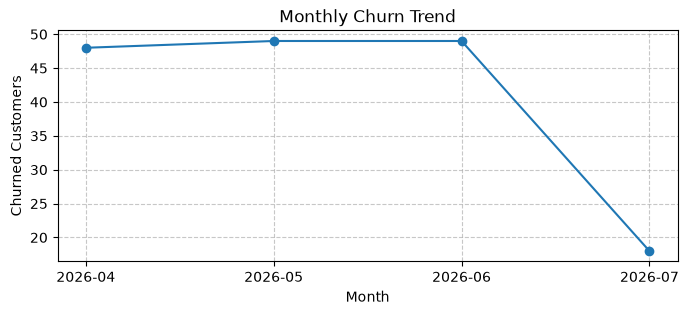

In [47]:
# Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, marker = 'o')

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

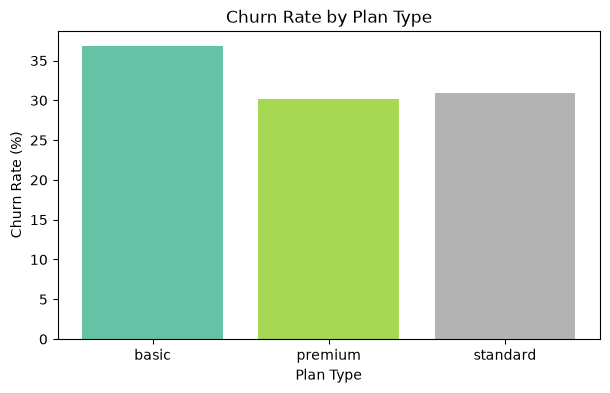

In [48]:
# Churn Rate by Plan type

chrun_plan = df_visual.groupby('plan_type')['churn_flag'].mean().mul(100)

colors = plt.cm.Set2(np.linspace(0,1,len(chrun_plan)))

plt.figure(figsize=(7,4))
plt.bar(chrun_plan.index, chrun_plan.values, color = colors)

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

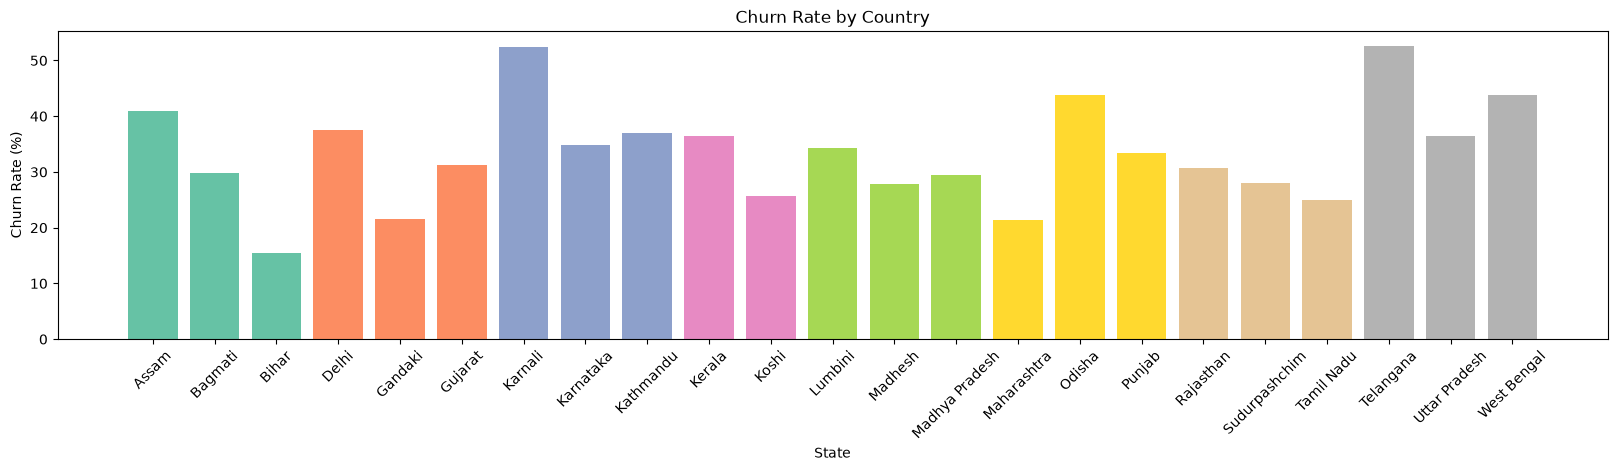

In [58]:
# Churn by States

churn_states = df_visual.groupby('state')['churn_flag'].mean().mul(100)

colors = plt.cm.Set2(np.linspace(0,1,len(churn_states)))

plt.figure(figsize=(20,4))
plt.bar(churn_states.index, churn_states.values, color = colors)

plt.title('Churn Rate by Country')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

## 5. Visulaization using Seaborn

In [50]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,standard,Annually,1,0,low,0
1,standard,Annually,28,0,low,0
2,standard,Annually,21,0,low,0
3,premium,Monthly,95,1,high,1
4,basic,Monthly,9,0,low,0


In [51]:
print(df_visual['plan_type'].unique())
print(df_visual['contract_type'].unique())
print(df_visual['churn_risk'].unique())

<StringArray>
['standard', 'premium', 'basic']
Length: 3, dtype: str
<StringArray>
['Annually', 'Monthly']
Length: 2, dtype: str
<StringArray>
['low', 'high', 'medium']
Length: 3, dtype: str


In [52]:
# encoding all the categorial columns to create a heatmap

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mapping = {
    'plan_type' : ['basic', 'standard', 'premium'],
    'contract_type' : ['Monthly', 'Annually'],
    'churn_risk' : ['low', 'high', 'medium']
}

for col, order in order_mapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,1,0,0,0
1,1,1,28,0,0,0
2,1,1,21,0,0,0
3,2,0,95,1,1,1
4,0,0,9,0,0,0


<Axes: >

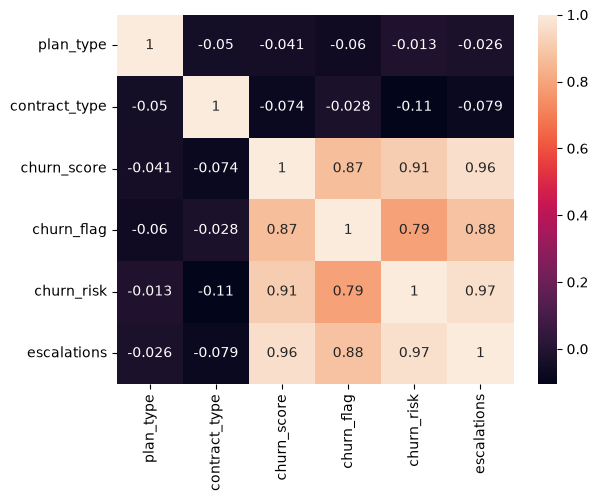

In [53]:
# creating a heatmap

sns.heatmap(df_encoded.corr(), annot = True)

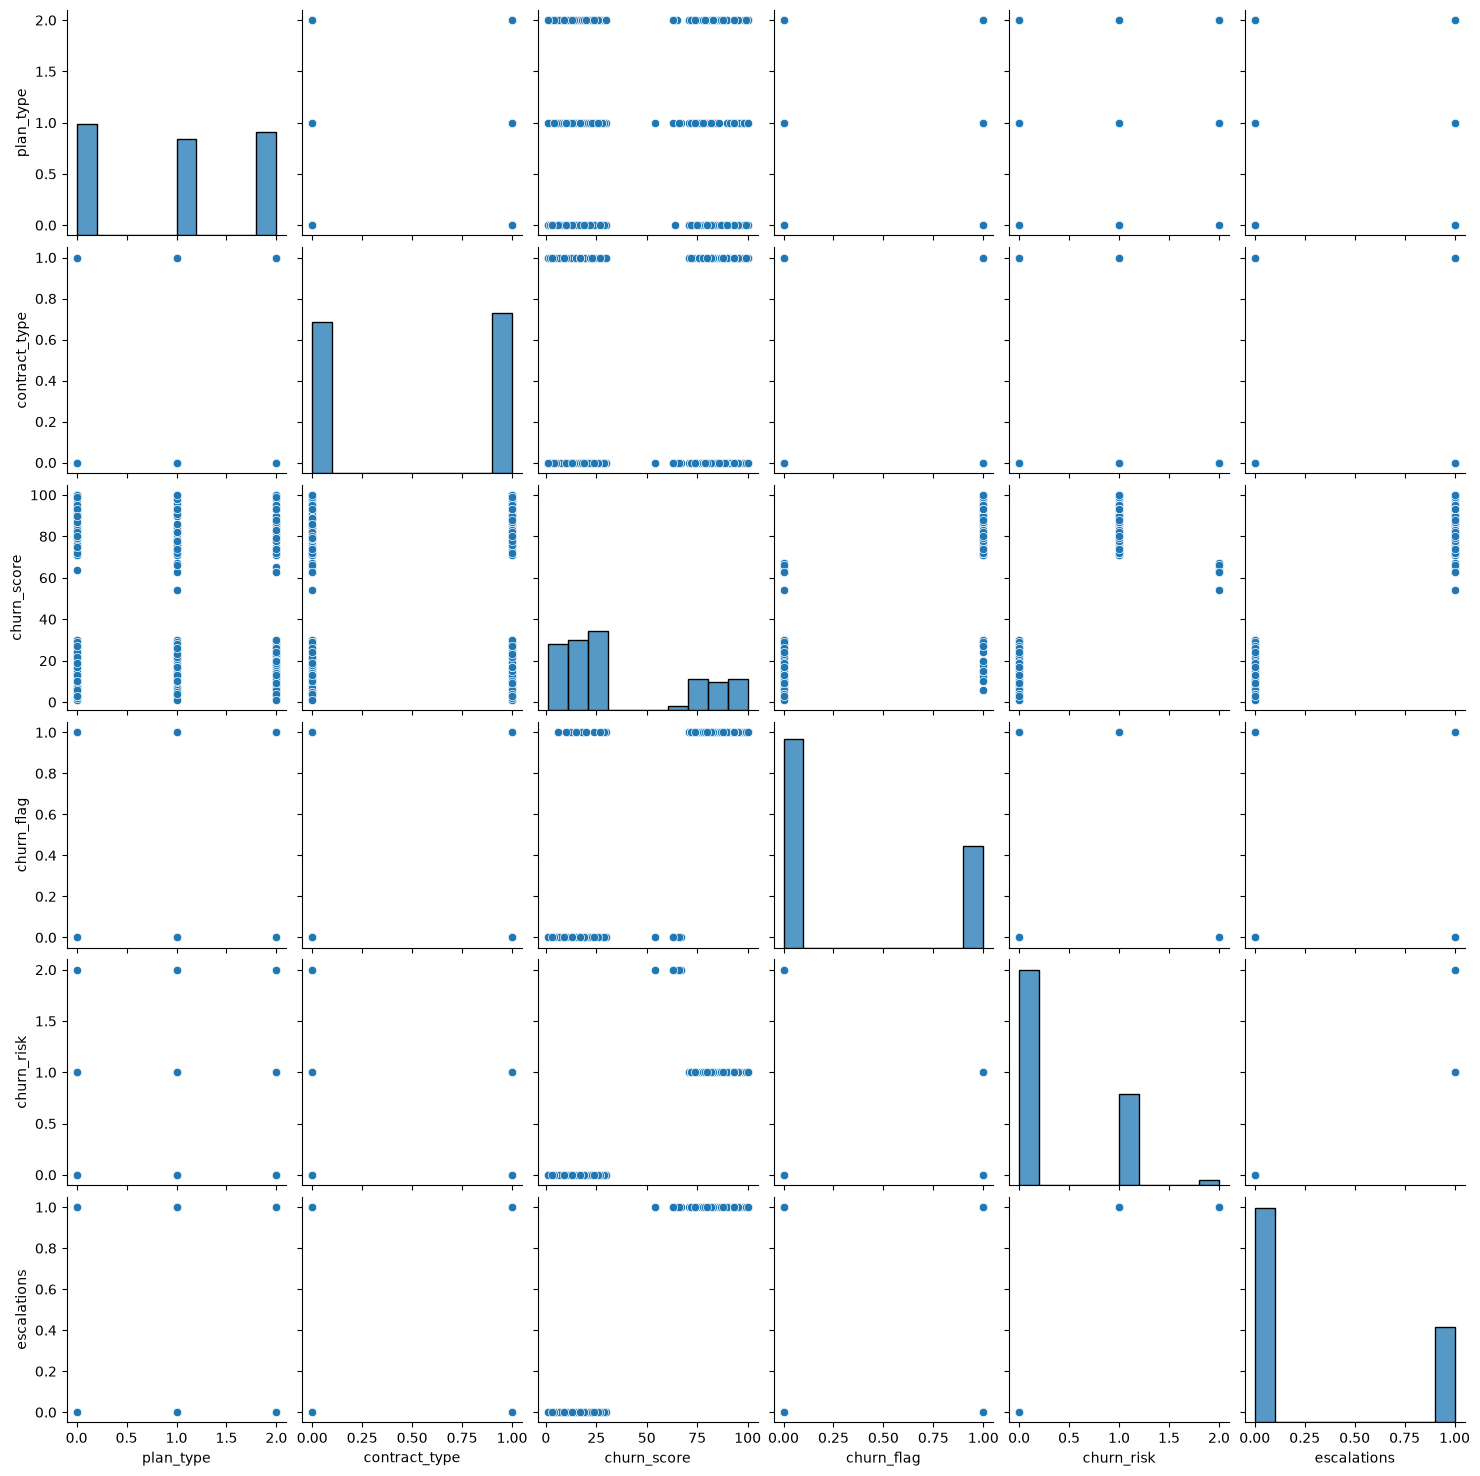

In [54]:
# pairplot - Plot pairwise relationships in a dataset

sns.pairplot(df_encoded)

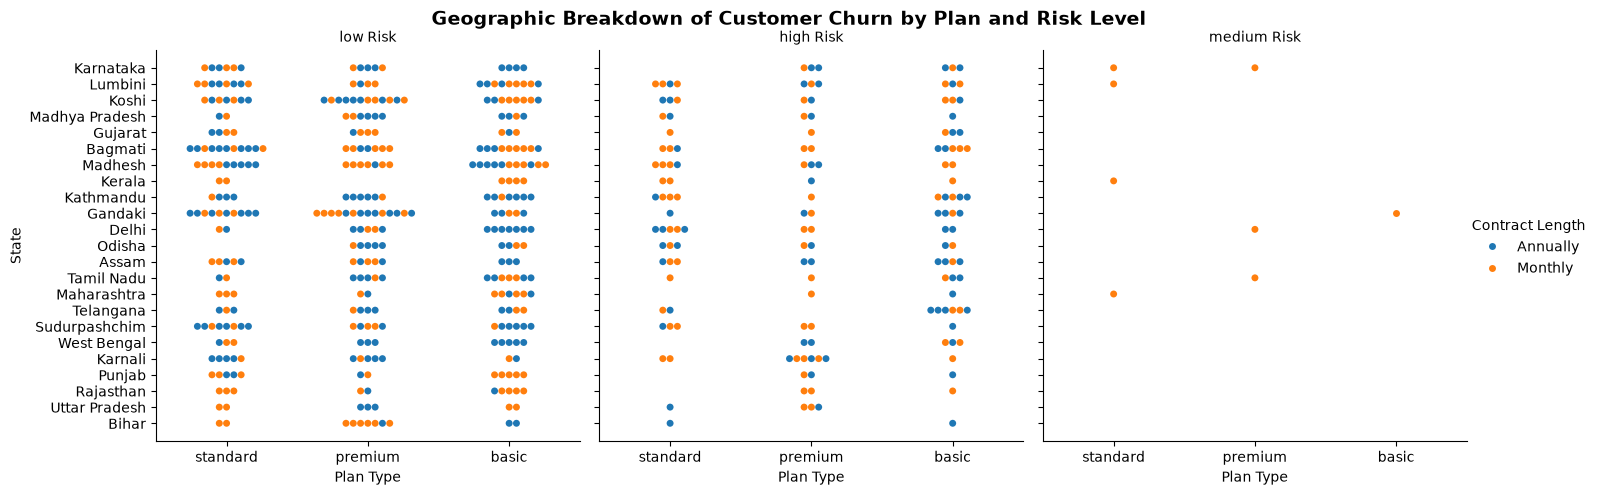

In [55]:
# catplt/Facegrid plot - multi-dim comparison

graph_1 = sns.catplot(data = df_visual,
            x = 'plan_type',
            y= 'state',
            hue= 'contract_type',
            col= 'churn_risk',
            kind='swarm')
graph_1.set_axis_labels("Plan Type", "State")
graph_1.set_titles("{col_name} Risk")
graph_1.fig.suptitle("Geographic Breakdown of Customer Churn by Plan and Risk Level", fontsize=14, fontweight='bold')
graph_1.legend.set_title("Contract Length")
graph_1.fig.subplots_adjust(top=0.9)

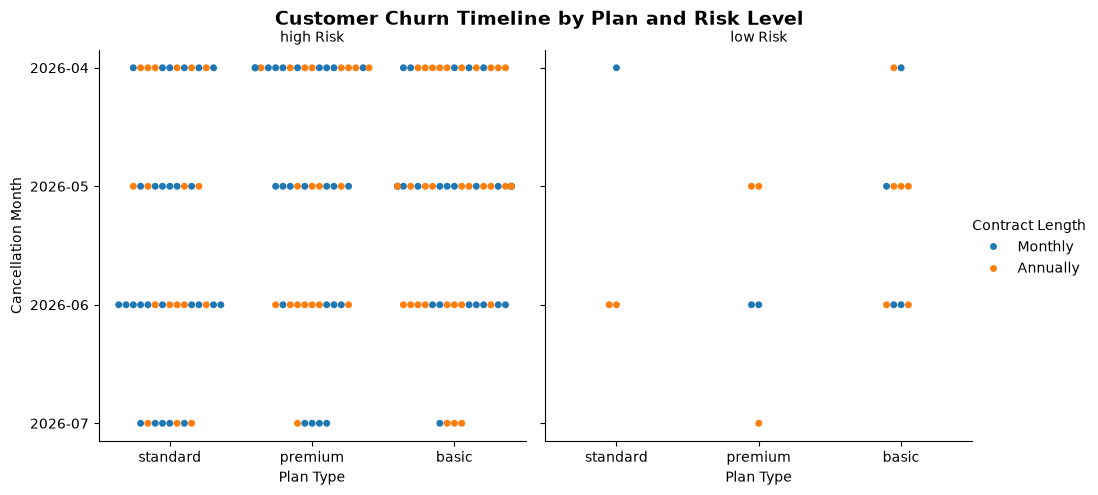

In [56]:
plot_data = df_visual.dropna(subset=['cancellation_month']).copy()

plot_data['cancellation_month'] = plot_data['cancellation_month'].astype(str)

plot_data = plot_data.sort_values('cancellation_month')

graph_2 = sns.catplot(data = plot_data.dropna(subset='cancellation_month'),
            x = 'plan_type',
            y= 'cancellation_month',
            hue= 'contract_type',
            col= 'churn_risk',
            kind='swarm')

graph_2.set_axis_labels("Plan Type", "Cancellation Month")
graph_2.set_titles("{col_name} Risk")
graph_2.fig.suptitle("Customer Churn Timeline by Plan and Risk Level", fontsize=14, fontweight='bold')
graph_2.legend.set_title("Contract Length")
graph_2.fig.subplots_adjust(top=0.9)

In [57]:
# pivot table using multiple cols and agg type

pd.pivot_table(df_visual,
               index = 'plan_type',
               values = ['monthly_charges', 'customerid', 'churn_flag'],
               aggfunc={
                   'monthly_charges' : 'sum',
                   'customerid' : 'nunique',
                   'churn_flag' : 'mean'
               }
               )

,churn_flag,customerid,monthly_charges
plan_type,,,
basic,0.368715,179,3414.21
premium,0.301205,166,3195.34
standard,0.309677,155,3077.45
